# Plot QI indices for different experiments

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

#from djimaging.utils import plot_utils, math_utils, trace_utils

# Create access to djimaging database

In [4]:
username = !whoami
username = username[0]
username

'fsalomon'

In [5]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [6]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [7]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [8]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [9]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [10]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-10-28 16:20:03,077][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-10-28 16:20:03,143][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [12]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

## Activate Schema

In [14]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Quality assessment

- show complete ChirpQI() table

In [15]:
ChirpQI()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,0.305357,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,0.325403,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,0.308556,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,0.241455,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,0.238274,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,6,1,0.339543,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,7,1,0.29292,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,8,1,0.295534,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,9,1,0.242879,0.2
Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,10,1,0.359355,0.2


## 2025, 5, 26

### Chirp Quality index
- show chirp quality index only for the fields from 26.05.2025

In [16]:
# Retrieve possible field keys for the date
unique_fields = (
    dj.U('field') & (ChirpQI() & {"date": datetime.date(2025, 5, 26)})
).fetch('field')

print(unique_fields)

['XY3' 'XY4' 'XY5' 'XY6' 'XY7' 'XY8']


In [17]:
# Select a field to plot the quality indices from
picked_field = "XY3"

In [18]:
# Define the key
key = {"date": datetime.date(2025, 5, 26), "field": picked_field, "stim_name": "gChirp"}

In [19]:
# Retrieve the quality indices and respective condition for the field
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")
print(chirp_qi)
print(condition)

[0.305357  0.325403  0.308556  0.241455  0.238274  0.339543  0.29292
 0.295534  0.242879  0.359355  0.351144  0.279231  0.260779  0.272383
 0.329686  0.291923  0.280794  0.24029   0.2421    0.288205  0.350547
 0.35674   0.315918  0.237832  0.279808  0.389849  0.333356  0.276758
 0.291607  0.39355   0.360303  0.367162  0.288594  0.345625  0.344688
 0.415849  0.263794  0.297299  0.301246  0.403659  0.397698  0.273676
 0.34454   0.408085  0.327199  0.283933  0.329187  0.329876  0.517498
 0.431124  0.438472  0.270079  0.311551  0.331849  0.372854  0.430989
 0.330375  0.342239  0.442665  0.423428  0.299245  0.314126  0.316844
 0.462837  0.378231  0.408822  0.307451  0.333173  0.297607  0.337574
 0.519343  0.467753  0.285149  0.307882  0.373836  0.20762   0.288223
 0.453656  0.280671  0.282994  0.297837  0.331175  0.373087  0.239341
 0.439278  0.239474  0.261239  0.30875   0.33821   0.385533  0.351519
 0.294142  0.278573  0.278283  0.321359  0.248808  0.347746  0.328142
 0.392006  0.250659  

<Axes: >

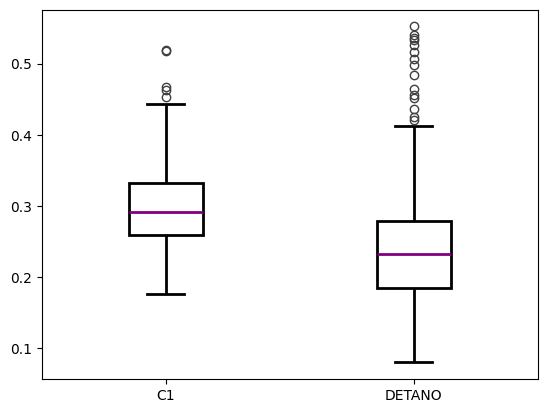

In [20]:
# Plot them in a boxplot
sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

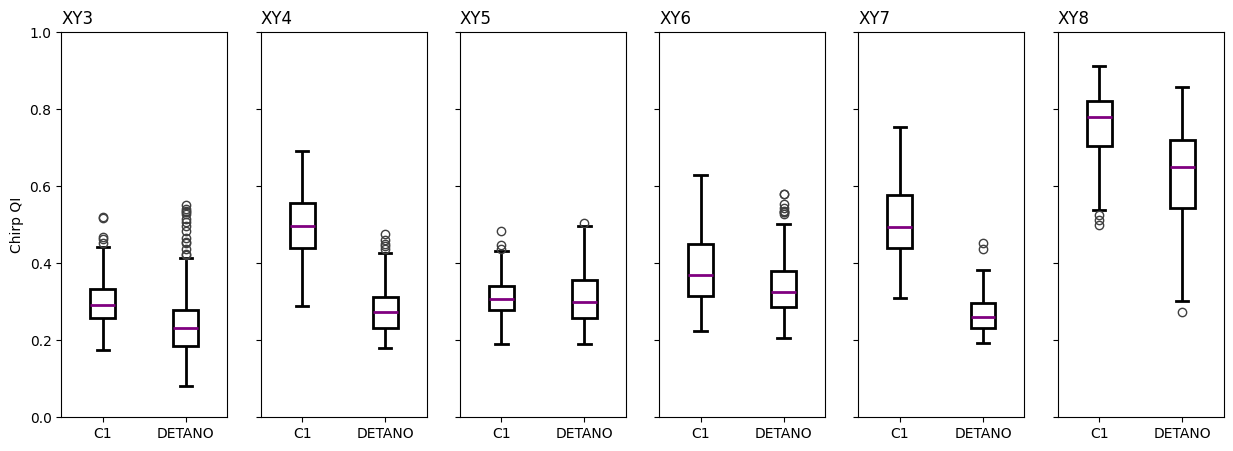

In [21]:
# Plot the quality indices on that date for all respective fields
# Define subplot figure
fig, axs = plt.subplots(1, 6, figsize=(15,5))

# Iterate over all fields
for i, unique_field in enumerate(unique_fields):

    # Generate the key to filter from
    key = {"date": datetime.date(2025, 5, 26), "field": unique_field, "stim_name": "gChirp"}

    # Fetch quality indices and condition in an array
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Create the boxplot via seaborn
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # Adjust the appearance of the plot
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Chirp QI")

# Save plot
plt.savefig("plots/20250526/chirp/ChirpQI_by_field.png",
            dpi=600,
            bbox_inches="tight")

### Moving Bar QI

In [22]:
OsDsIndexes()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,ds_index direction selectivity index as resulting vector length (absolute of projection on complex exponential),ds_pvalue p-value indicating the percentile of the vector length in null distribution,pref_dir preferred direction,os_index orientation selectivity index in analogy to ds_index,os_pvalue analogous to ds_pvalue for orientation tuning,pref_or preferred orientation,on_off on off index based on time kernel,d_qi quality index for moving bar response,dir_component,time_component,time_component_dt,surrogate_v computed by projecting on time,surrogate_dsi DSI of surrogate v
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,1,1,0.257711,0.47,-1.46939,0.301269,0.47,2.00489,-0.24,0.596243,=BLOB=,=BLOB=,0.128,=BLOB=,0.305492
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,2,1,0.314595,0.06,-1.85228,0.119472,0.56,0.245059,-0.33,0.764654,=BLOB=,=BLOB=,0.128,=BLOB=,0.310511
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,3,1,0.47076,0.0,-2.4298,0.0901835,0.79,2.04305,-0.72,0.654797,=BLOB=,=BLOB=,0.128,=BLOB=,0.363988
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,4,1,0.270836,0.1,-1.9452,0.209763,0.28,0.939792,-0.11,0.513283,=BLOB=,=BLOB=,0.128,=BLOB=,0.266774
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,5,1,0.492645,0.56,-1.22575,0.329828,0.13,2.21457,0.45,0.52846,=BLOB=,=BLOB=,0.128,=BLOB=,0.138685
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,6,1,0.208503,0.54,-1.41752,0.191897,0.64,1.03878,0.13,0.630613,=BLOB=,=BLOB=,0.128,=BLOB=,0.217317
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,7,1,0.181318,0.58,-0.874923,0.311513,0.32,0.904825,0.19,0.6282,=BLOB=,=BLOB=,0.128,=BLOB=,0.181177
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,8,1,0.358492,0.03,-2.25166,0.0700411,0.97,2.49771,-0.18,0.577675,=BLOB=,=BLOB=,0.128,=BLOB=,0.363924
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,9,1,0.133842,0.83,-1.9818,0.17654,0.77,0.0222022,0.06,0.554961,=BLOB=,=BLOB=,0.128,=BLOB=,0.110515
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,10,1,0.198733,0.26,-0.0888499,0.29726,0.17,0.608437,-0.0,0.661363,=BLOB=,=BLOB=,0.128,=BLOB=,0.249527


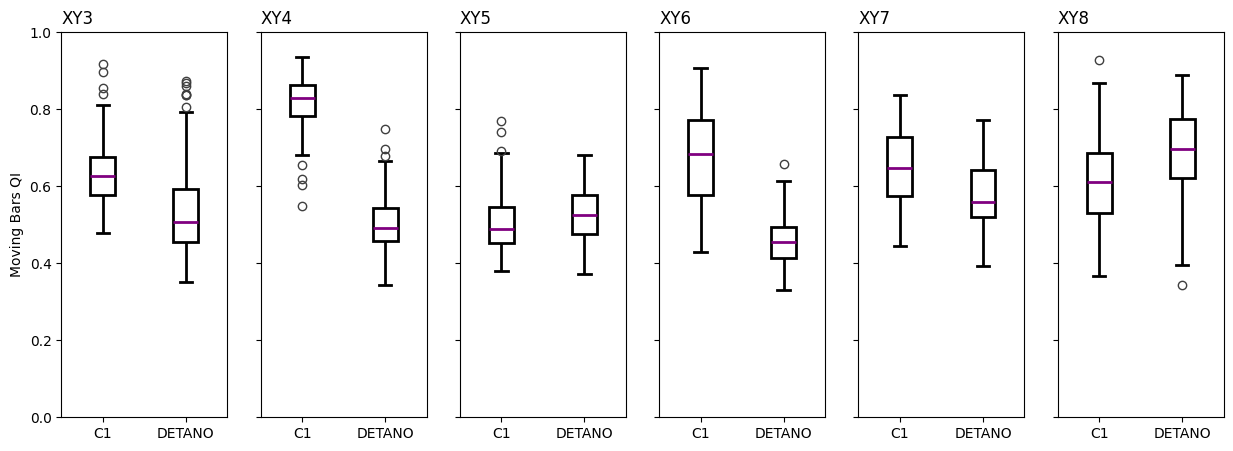

In [23]:
# Plot moving bar quality indices
# Subplots for figure
fig, axs = plt.subplots(1, 6, figsize=(15,5))

# Itterate over all fields
for i, unique_field in enumerate(unique_fields):

    # Define key
    key = {"date": datetime.date(2025, 5, 26), "field": unique_field, "stim_name": "movingbar"}

    # Fetch moving bars qi, and respective conditions
    movingbars_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

    # Plot the graph
    sns.boxplot(x=condition,
            y=movingbars_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # adjust appearance of the plots
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Moving Bars QI")

# Save the figure
plt.savefig("plots/20250526/mb/MBQI_by_field.png",
            dpi=600,
            bbox_inches="tight")

## 2025, 6, 12

### Z-shift

- check QI chirp and mb for the data with manual shifted Z-focus

In [24]:
ChirpQI() & {"date": datetime.date(2025, 6, 12)}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,1,1,0.330081,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,2,1,0.288865,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,3,1,0.29579,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,4,1,0.246735,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,5,1,0.270035,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,6,1,0.282367,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,7,1,0.256305,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,8,1,0.419769,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,9,1,0.404929,0.2
Salomon,2025-06-12,2,1,XY,RR,d,gChirp,Z1,10,1,0.26575,0.2


#### Chirp

In [25]:
# Retrieve key for that field, called XY
key = {"field": "XY", "date": datetime.date(2025, 6, 12)}

# Fetsch chirp quality index and respective condition in an array
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")
print(chirp_qi)
print(condition)

[0.330081 0.288865 0.29579  0.246735 0.270035 0.282367 0.256305 0.419769
 0.404929 0.26575  0.292364 0.303227 0.312747 0.304215 0.242721 0.338465
 0.417193 0.215879 0.269358 0.274776 0.364371 0.250896 0.257822 0.287728
 0.276247 0.386501 0.266737 0.272618 0.257881 0.227368 0.253882 0.292677
 0.332664 0.21767  0.397382 0.264553 0.325634 0.197308 0.324679 0.289051
 0.281036 0.291301 0.247804 0.205652 0.244998 0.266057 0.251665 0.2593
 0.402533 0.326734 0.300024 0.324738 0.306927 0.266971 0.290443 0.27498
 0.219381 0.223781 0.278018 0.32992  0.300632 0.236004 0.259463 0.242003
 0.330737 0.298773 0.277588 0.351694 0.37989  0.278837 0.228826 0.280901
 0.264063 0.36982  0.256893 0.236147 0.237955 0.261756 0.34747  0.318952
 0.238173 0.258909 0.248932 0.308449 0.222278 0.275183 0.255117 0.308958
 0.276447 0.325711 0.232435 0.285986 0.317492 0.26357  0.297744 0.280938
 0.299123 0.378508 0.332888 0.2558   0.349935 0.340924 0.331115 0.325868
 0.429082 0.290647 0.285474 0.311373 0.348209 0.385504

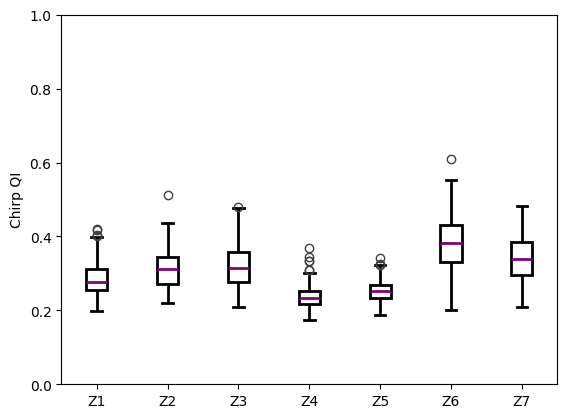

In [26]:
# Plot chirp quality index
sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

# Adjust appearance of the plot
plt.ylim([0,1])
plt.ylabel("Chirp QI")

# Save the plot
plt.savefig("plots/20250612/chirp/ChirpQI_Z_offset.png",
            dpi=600,
            bbox_inches="tight")

#### Moving Bars

In [27]:
# Define key
key = {"field": "XY", "date": datetime.date(2025, 6, 12)}

# Fetsch mb quality and respective condition
movingbars_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")
print(movingbars_qi)
print(condition)

[0.574294 0.595949 0.726033 0.529808 0.521954 0.614608 0.512472 0.633981
 0.661468 0.450911 0.528407 0.546333 0.520626 0.568264 0.52884  0.644618
 0.614146 0.58277  0.580141 0.539134 0.591751 0.585997 0.543726 0.56476
 0.519641 0.551861 0.550014 0.565085 0.522719 0.488512 0.589692 0.581265
 0.582113 0.476463 0.576088 0.50467  0.542414 0.464774 0.523217 0.558259
 0.464083 0.553243 0.481066 0.5118   0.500184 0.479538 0.510745 0.535347
 0.575894 0.557908 0.551111 0.613264 0.554051 0.427726 0.540453 0.610645
 0.451113 0.41394  0.572943 0.589079 0.520117 0.520101 0.600916 0.526164
 0.623918 0.573269 0.543168 0.601249 0.643365 0.60265  0.592859 0.569836
 0.558625 0.542804 0.563712 0.493459 0.542692 0.600186 0.659057 0.596026
 0.568415 0.536956 0.484209 0.676576 0.459673 0.519225 0.49513  0.576189
 0.564621 0.601301 0.559259 0.609922 0.581772 0.617455 0.583687 0.671427
 0.647827 0.557311 0.542837 0.539265 0.664938 0.560334 0.523085 0.498226
 0.543124 0.478436 0.498316 0.47257  0.530865 0.5650

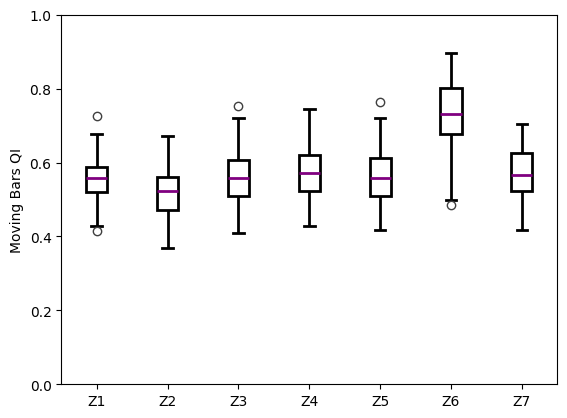

In [28]:
# Plot mb quality
sns.boxplot(x=condition,
            y=movingbars_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

# Adjust appearance of the plot
plt.ylim([0,1])
plt.ylabel("Moving Bars QI")

# Save that plot
plt.savefig("plots/20250612/mb/MBQI_offset.png",
            dpi=600,
            bbox_inches="tight")

### Rundown

- plot quality indices for the rundown

#### Chirp

In [29]:
# Retrieve the fields that were measured
unique_fields = (
    dj.U('field') & (ChirpQI() & {"date": datetime.date(2025, 6, 12)})
).fetch('field')

# Delete the field XY, already plotted before
unique_fields = np.delete(unique_fields, 0)

# Arrange the fields in order
unique_fields = unique_fields[np.argsort([int(s[2:]) for s in unique_fields])]

print(unique_fields)

['XY8' 'XY9' 'XY10']


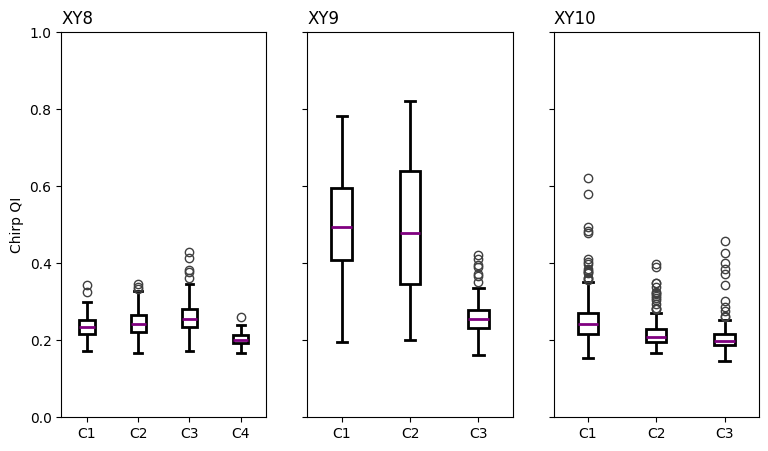

In [30]:
# Plot the chirpqi for the 3 fields
# Subplot figure
fig, axs = plt.subplots(1, 3, figsize=(9,5))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a key
    key = {"date": datetime.date(2025, 6, 12), "field": unique_field, "stim_name": "gChirp"}

    # Fetsch chirpqi and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the chirpqi
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Chirp QI")

# Save the figure
plt.savefig("plots/20250612/chirp/ChirpQI_rundown_by_field.png",
            dpi=600,
            bbox_inches="tight")

#### Moving Bars

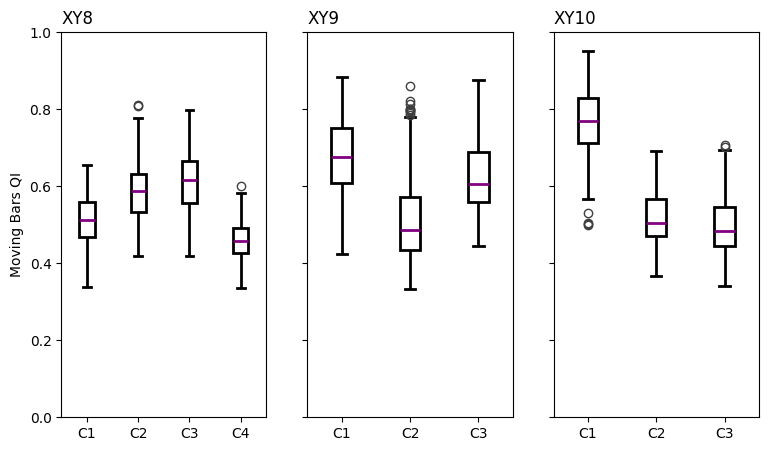

In [31]:
# Plot rundown of moving bar quality index
# Subplot figure
fig, axs = plt.subplots(1, 3, figsize=(9,5))

# Itterate over fields
for i, unique_field in enumerate(unique_fields):

    # Define a key for the MBQI
    key = {"date": datetime.date(2025, 6, 12), "field": unique_field, "stim_name": "movingbar"}

    # Fetsch MBQI and respective condition
    movingbars_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

    # Plot the MBQI
    sns.boxplot(x=condition,
            y=movingbars_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Moving Bars QI")

# Save the plot
plt.savefig("plots/20250612/mb/MBQI_rundown_by_field.png",
            dpi=600,
            bbox_inches="tight")

## 2025, 7, 10

In [32]:
# Define the fields for the respective date
unique_fields = (
    dj.U('field') & (ChirpQI() & {"date": datetime.date(2025, 7, 10)})
).fetch('field')

# Arrange them in ascending order
unique_fields = unique_fields[np.argsort([int(s[2:]) for s in unique_fields])]

print(unique_fields)

['XY1' 'XY2' 'XY3']


### Chirp

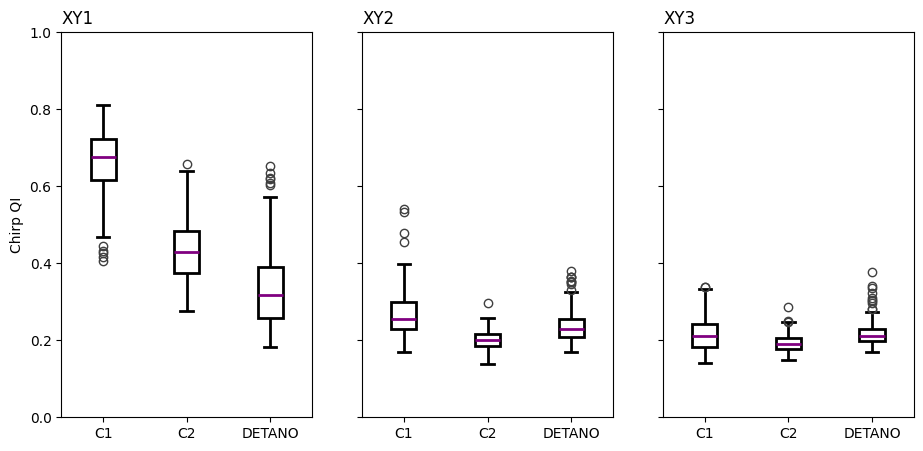

In [33]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 3, figsize=(11,5))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 7, 10), "field": unique_field, "stim_name": "gChirp"}

    # Fetsch the ChirpQI, and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Chirp QI")

# Save the figure
plt.savefig("plots/20250710/chirp/ChirpQI_by_field.png",
            dpi=600,
            bbox_inches="tight")

### Moving Bars

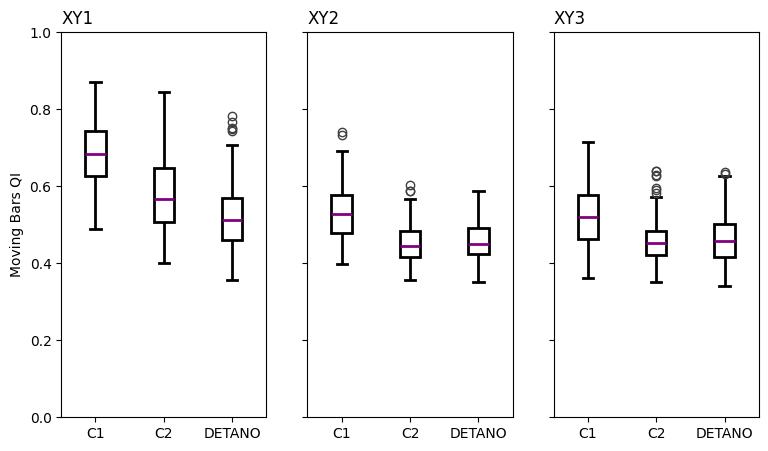

In [34]:
# Subplot for the MBQI of the respective date
fig, axs = plt.subplots(1, 3, figsize=(9,5))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define the key
    key = {"date": datetime.date(2025, 7, 10), "field": unique_field, "stim_name": "movingbar"}

    # Fetsch the MBQI, and respective condition
    movingbars_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

    # Plot the MBQI
    sns.boxplot(x=condition,
            y=movingbars_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3,
            ax=axs[i])

    # Adjust the appearance of the plot
    axs[i].set_ylim([0,1])

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Moving Bars QI")

# Save the figure
plt.savefig("plots/20250710/mb/MBQI_by_field.png",
            dpi=600,
            bbox_inches="tight")

## 2025, 9, 8

### Global ChirpQI

In [35]:
# Define the fields for the respective date
unique_fields = (
    dj.U('field') & (ChirpQI() & {"date": datetime.date(2025, 9, 8)})
).fetch('field')

# Arrange them in ascending order
unique_fields = unique_fields[np.argsort([int(s[2:]) for s in unique_fields])]

print(unique_fields)

['XY1' 'XY2' 'XY3' 'XY4' 'XY6' 'XY7' 'XY8']


#### By field

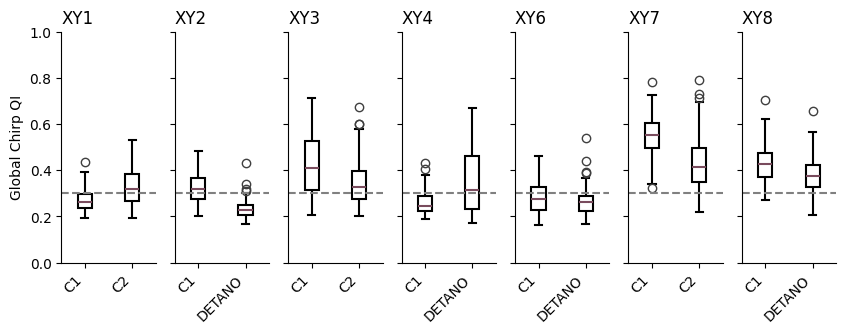

In [40]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 7, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 9, 8), "field": unique_field, "stim_name": "gChirp"}

    # Fetsch the ChirpQI, and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Global Chirp QI")
    axs[i].axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Save the figure
plt.savefig("plots/20250908/gchirp/gchirpQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

#### By condition

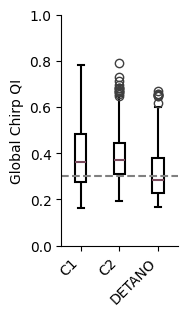

In [41]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 9, 8), "stim_name": "gChirp"}

# Fetsch the ChirpQI, and respective condition
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

ax = sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("Global Chirp QI")

plt.savefig("plots/20250908/gchirp/gchirpQI.png",
            dpi=300,
            bbox_inches="tight")

### Local Chirp QI

#### By field

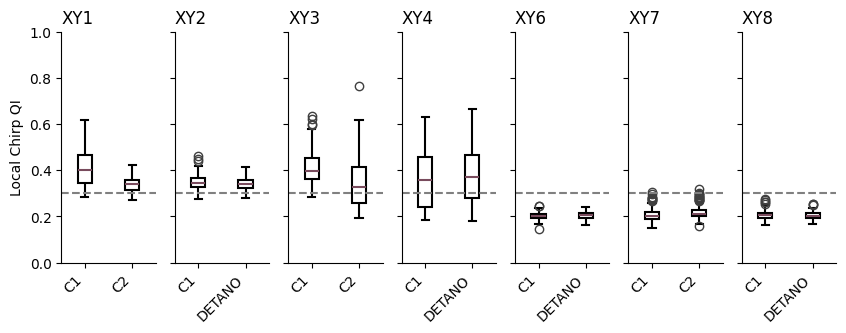

In [42]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 7, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 9, 8), "field": unique_field, "stim_name": "lChirp"}

    # Fetsch the ChirpQI, and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Local Chirp QI")
    axs[i].axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Save the figure
plt.savefig("plots/20250908/lchirp/lchirpQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

#### By condition

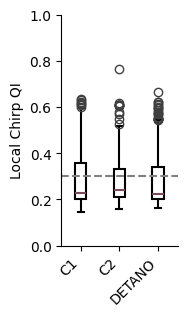

In [43]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 9, 8), "stim_name": "lChirp"}

# Fetsch the ChirpQI, and respective condition
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

ax = sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("Local Chirp QI")

plt.savefig("plots/20250908/lchirp/lchirpQI.png",
            dpi=300,
            bbox_inches="tight")

### Moving Bars

#### By field

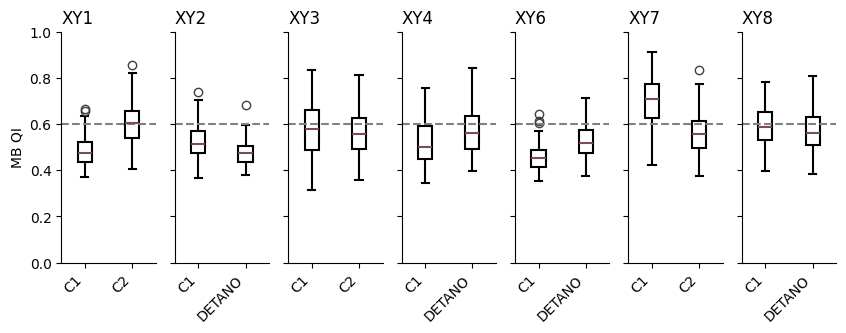

In [45]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 7, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 9, 8), "field": unique_field, "stim_name": "movingbar"}

    # Fetsch the ChirpQI, and respective condition
    mb_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=mb_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("MB QI")
    axs[i].axhline(y=0.60, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

plt.savefig("plots/20250908/mb/MBQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

#### By condition

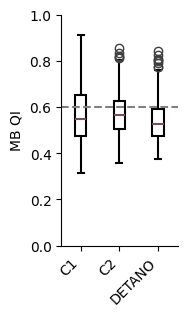

In [46]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 9, 8), "stim_name": "movingbar"}

# Fetsch the ChirpQI, and respective condition
mb_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

ax = sns.boxplot(x=condition,
            y=mb_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.60, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0,1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("MB QI")

plt.savefig("plots/20250908/mb/MBQI.png",
            dpi=300,
            bbox_inches="tight")

## 2025, 10, 23

### Global Chirp

In [47]:
# Define the fields for the respective date
unique_fields = (
    dj.U('field') & (ChirpQI() & {"date": datetime.date(2025, 10, 23)})
).fetch('field')

# Arrange them in ascending order
unique_fields = unique_fields[np.argsort([int(s[2:]) for s in unique_fields])]

print(unique_fields)

['XY1' 'XY2' 'XY3' 'XY4' 'XY5' 'XY6' 'XY7' 'XY8']


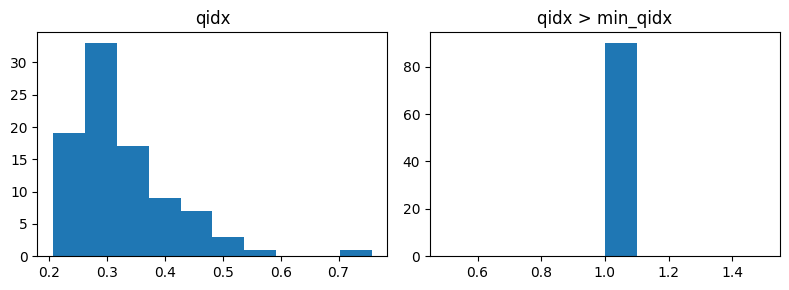

In [21]:
(ChirpQI() & key).plot()

#### By field

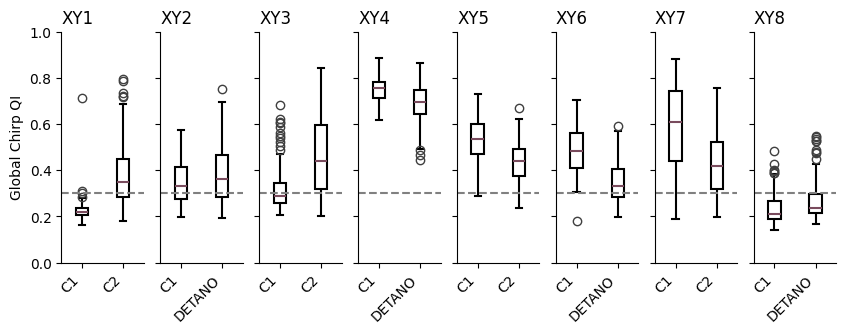

In [48]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 8, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 10, 23), "field": unique_field, "stim_name": "gChirp"}

    # Fetsch the ChirpQI, and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Global Chirp QI")
    axs[i].axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Save the figure
plt.savefig("plots/20251023/gchirp/gchirpQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

#### By condition

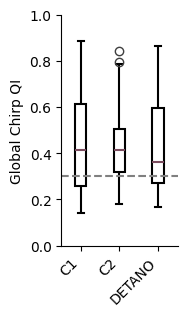

In [49]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 10, 23), "stim_name": "gChirp"}

# Fetsch the ChirpQI, and respective condition
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

ax = sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("Global Chirp QI")

plt.savefig("plots/20251023/gchirp/gchirpQI.png",
            dpi=300,
            bbox_inches="tight")

In [15]:
OsDsIndexes()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,ds_index direction selectivity index as resulting vector length (absolute of projection on complex exponential),ds_pvalue p-value indicating the percentile of the vector length in null distribution,pref_dir preferred direction,os_index orientation selectivity index in analogy to ds_index,os_pvalue analogous to ds_pvalue for orientation tuning,pref_or preferred orientation,on_off on off index based on time kernel,d_qi quality index for moving bar response,dir_component,time_component,time_component_dt,surrogate_v computed by projecting on time,surrogate_dsi DSI of surrogate v
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,1,1,0.332048,0.06,-1.71109,0.137961,0.33,2.38679,-0.23,0.667817,=BLOB=,=BLOB=,0.128,=BLOB=,0.423561
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,2,1,0.506292,0.02,-2.10308,0.11989,0.91,1.05204,-0.36,0.788609,=BLOB=,=BLOB=,0.128,=BLOB=,0.53199
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,3,1,0.411816,0.14,-2.44159,0.134719,0.96,2.45371,-0.11,0.722388,=BLOB=,=BLOB=,0.128,=BLOB=,0.378891
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,4,1,0.211053,0.58,3.11599,0.224537,0.91,0.885654,-0.54,0.683501,=BLOB=,=BLOB=,0.128,=BLOB=,0.231086
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,5,1,0.519728,0.07,-2.34259,0.348073,0.38,0.585672,0.08,0.690169,=BLOB=,=BLOB=,0.128,=BLOB=,0.372265
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,6,1,0.0924344,0.24,-0.198883,0.383195,0.48,0.0295907,-0.31,0.631704,=BLOB=,=BLOB=,0.128,=BLOB=,0.344803
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,7,1,0.498549,0.02,-2.37765,0.205384,0.55,2.59547,-0.31,0.713045,=BLOB=,=BLOB=,0.128,=BLOB=,0.512115
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,8,1,0.509254,0.02,-2.45164,0.0717104,0.97,0.0817144,-0.35,0.822728,=BLOB=,=BLOB=,0.128,=BLOB=,0.500441
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,9,1,0.165916,0.76,1.88261,0.339158,0.39,2.7123,0.68,0.717441,=BLOB=,=BLOB=,0.128,=BLOB=,0.176952
Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,10,1,0.418335,0.12,-1.41873,0.244818,0.64,1.9429,-0.17,0.636709,=BLOB=,=BLOB=,0.128,=BLOB=,0.442509


### Local Chirp

#### By field

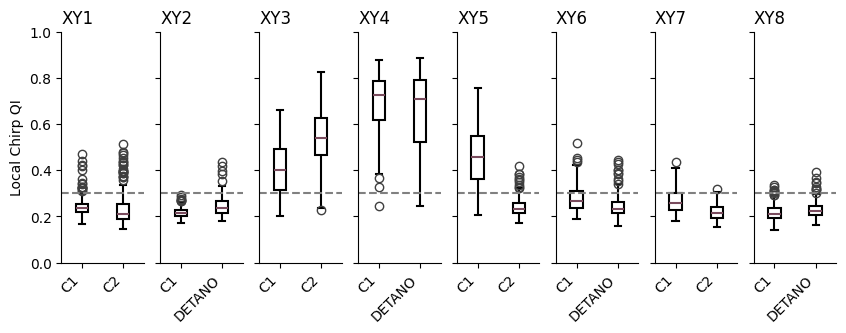

In [50]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 8, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 10, 23), "field": unique_field, "stim_name": "lChirp"}

    # Fetsch the ChirpQI, and respective condition
    chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("Local Chirp QI")
    axs[i].axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Save the figure
plt.savefig("plots/20251023/lchirp/lchirpQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

#### By condition

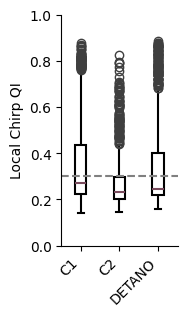

In [51]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 10, 23), "stim_name": "lChirp"}

# Fetsch the ChirpQI, and respective condition
chirp_qi, condition = (ChirpQI() & key).fetch("qidx", "cond2")

ax = sns.boxplot(x=condition,
            y=chirp_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.30, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("Local Chirp QI")

plt.savefig("plots/20251023/lchirp/lchirpQI.png",
            dpi=300,
            bbox_inches="tight")

### Moving bars

#### By field

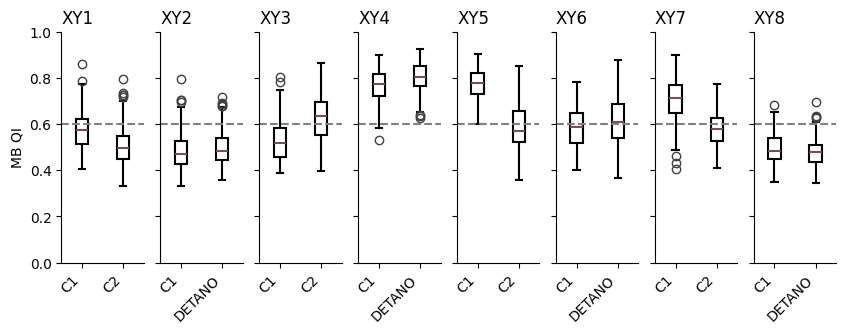

In [53]:
# Subplot figure for ChirpQI
fig, axs = plt.subplots(1, 8, figsize=(10,3))

# Itterate over the fields
for i, unique_field in enumerate(unique_fields):

    # Define a field key
    key = {"date": datetime.date(2025, 10, 23), "field": unique_field, "stim_name": "movingbar"}

    # Fetsch the ChirpQI, and respective condition
    mb_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

    # Plot the ChirpQI
    sns.boxplot(x=condition,
            y=mb_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3,
            ax=axs[i])

    # Adjust appearance of the plot
    axs[i].set_ylim([0,1])

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    if i != 0: 
        axs[i].set_ylabel("")
        axs[i].set_yticklabels([])

    axs[i].set_title(unique_field, loc="left")
    axs[0].set_ylabel("MB QI")
    axs[i].axhline(y=0.60, color="gray", linestyle="--", linewidth=1.5)

    axs[i].tick_params(axis='x', rotation=45)
    for label in axs[i].get_xticklabels():
        label.set_horizontalalignment('right')

plt.savefig("plots/20251023/mb/MBQI_by_field.png",
            dpi=300,
            bbox_inches="tight")

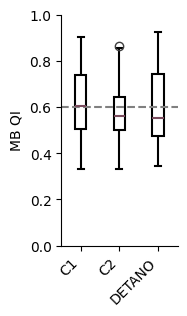

In [54]:
plt.figure(figsize=(1.5, 3))

# Define a field key
key = {"date": datetime.date(2025, 10, 23), "stim_name": "movingbar"}

# Fetsch the ChirpQI, and respective condition
mb_qi, condition = (OsDsIndexes() & key).fetch("d_qi", "cond2")

ax = sns.boxplot(x=condition,
            y=mb_qi,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color="#794b5d", linewidth=1.5),
            width=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=0.60, color="gray", linestyle="--", linewidth=1.5)

ax.set_ylim(0,1)

plt.xticks(rotation=45, ha="right")

plt.xlabel(None)
plt.ylabel("MB QI")

plt.savefig("plots/20251023/mb/MBQI.png",
            dpi=300,
            bbox_inches="tight")

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Load Data

In [2]:
chirp_qi = np.load("dataframes/ChirpQI.npy", allow_pickle=True)
chirp_qi

array([('Salomon', datetime.date(2025, 5, 26), 1, 1, 'XY3', 'LR', 'n', 'gChirp', 'C1',  1, 1, 0.24899 , 0.2),
       ('Salomon', datetime.date(2025, 5, 26), 1, 1, 'XY3', 'LR', 'n', 'gChirp', 'C1',  2, 1, 0.358356, 0.2),
       ('Salomon', datetime.date(2025, 5, 26), 1, 1, 'XY3', 'LR', 'n', 'gChirp', 'C1',  3, 1, 0.305937, 0.2),
       ...,
       ('Salomon', datetime.date(2025, 7, 10), 2, 1, 'XY2', 'RR', 'd', 'gChirp', 'DETANO', 84, 1, 0.267406, 0.2),
       ('Salomon', datetime.date(2025, 7, 10), 2, 1, 'XY2', 'RR', 'd', 'gChirp', 'DETANO', 85, 1, 0.37233 , 0.2),
       ('Salomon', datetime.date(2025, 7, 10), 2, 1, 'XY2', 'RR', 'd', 'gChirp', 'DETANO', 86, 1, 0.355115, 0.2)],
      dtype=[('experimenter', 'O'), ('date', 'O'), ('exp_num', '<i8'), ('raw_id', '<i8'), ('field', 'O'), ('region', 'O'), ('cond1', 'O'), ('stim_name', 'O'), ('cond2', 'O'), ('roi_id', '<i8'), ('preprocess_id', '<i8'), ('qidx', '<f8'), ('min_qidx', '<f8')])

In [3]:
chirp_qi = pd.DataFrame(chirp_qi)
chirp_qi

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,qidx,min_qidx
0,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,0.248990,0.2
1,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,0.358356,0.2
2,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,0.305937,0.2
3,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,0.347286,0.2
4,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,0.306760,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3216,Salomon,2025-07-10,2,1,XY2,RR,d,gChirp,DETANO,82,1,0.365432,0.2
3217,Salomon,2025-07-10,2,1,XY2,RR,d,gChirp,DETANO,83,1,0.252612,0.2
3218,Salomon,2025-07-10,2,1,XY2,RR,d,gChirp,DETANO,84,1,0.267406,0.2
3219,Salomon,2025-07-10,2,1,XY2,RR,d,gChirp,DETANO,85,1,0.372330,0.2


In [5]:
osds_indices = np.load("dataframes/OsDsIndexes.npy", allow_pickle=True)
osds_indices

array([('Salomon', datetime.date(2025, 5, 26), 1, 1, 'XY3', 'LR', 'n', 'movingbar', 'C1',  1, 1, 0.332048, 0.06, -1.71109 , 0.137961, 0.33, 2.38679, -0.23, 0.667817, array([0.24573421, 0.39277285, 0.        , 0.4972195 , 0.6632779 ,
              0.57718956, 0.8767098 , 1.        ], dtype=float32), array([-0.11944372, -0.01224269, -0.05192821, -0.12034047,  0.03998114,
               0.00781187,  0.12772802,  0.12843396,  0.02355766,  0.04100728,
              -0.07567824,  0.07626382, -0.07147012, -0.06436978,  0.14866853,
               0.11479257,  0.28901464,  0.20435798,  0.00702572,  0.2815645 ,
               0.28460035,  0.55976367,  1.        ,  0.94872653,  0.77837527,
               0.5230529 ,  0.23562643,  0.12264502,  0.24586415,  0.24683909,
              -0.00957514,  0.01630582, -0.1546585 ], dtype=float32), 0.128, array([0.0706095 , 0.11667845, 0.        , 0.60321045, 0.8206346 ,
              0.45714703, 1.        , 0.9960041 ], dtype=float32), 0.423561)             

In [6]:
osds_indices = pd.DataFrame(osds_indices)
osds_indices

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,...,os_index,os_pvalue,pref_or,on_off,d_qi,dir_component,time_component,time_component_dt,surrogate_v,surrogate_dsi
0,Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,1,...,0.137961,0.33,2.386790,-0.23,0.667817,"[0.24573421, 0.39277285, 0.0, 0.4972195, 0.663...","[-0.11944372, -0.012242693, -0.051928215, -0.1...",0.128,"[0.0706095, 0.11667845, 0.0, 0.60321045, 0.820...",0.423561
1,Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,2,...,0.119890,0.91,1.052040,-0.36,0.788609,"[0.0, 0.27183026, 0.037374318, 0.27135354, 0.7...","[-0.13564333, -0.112873755, 0.027859334, -0.06...",0.128,"[0.0, 0.21178724, 0.046324935, 0.28526956, 0.8...",0.531990
2,Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,3,...,0.134719,0.96,2.453710,-0.11,0.722388,"[0.0, 0.18441653, 0.14580746, 0.7200298, 1.0, ...","[-0.13110249, -0.007511495, -0.08948312, 0.004...",0.128,"[0.06488255, 0.43550494, 0.0, 0.576219, 0.8904...",0.378891
3,Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,4,...,0.224537,0.91,0.885654,-0.54,0.683501,"[0.41303286, 0.77999616, 0.5118477, 0.76767784...","[0.08320944, 0.09287325, 0.034572747, -0.02197...",0.128,"[0.49737453, 0.11458632, 0.8467099, 0.0, 0.642...",0.231086
4,Salomon,2025-05-26,1,1,XY3,LR,n,movingbar,C1,5,...,0.348073,0.38,0.585672,0.08,0.690169,"[0.24657477, 0.20465624, 0.0, 0.18397033, 0.73...","[0.056072015, 0.09644703, 0.089882776, 0.03449...",0.128,"[0.22090366, 0.12654921, 0.44531193, 0.0, 0.33...",0.372265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,Salomon,2025-07-10,2,1,XY2,RR,d,movingbar,DETANO,82,...,0.271086,0.53,2.624230,0.06,0.361167,"[0.60026884, 0.30770087, 0.48921517, 0.3278874...","[-0.1313402, -0.05803134, 0.022732068, 0.40527...",0.128,"[0.70435375, 0.20471802, 0.23179093, 0.2907842...",0.181311
3218,Salomon,2025-07-10,2,1,XY2,RR,d,movingbar,DETANO,83,...,0.270810,0.19,2.556690,0.12,0.460148,"[0.94057906, 0.0, 0.6394745, 0.87214744, 0.585...","[0.48748577, -0.26276526, -0.06535702, 0.00199...",0.128,"[1.0, 0.0, 0.46969908, 0.84995544, 0.5066894, ...",0.062052
3219,Salomon,2025-07-10,2,1,XY2,RR,d,movingbar,DETANO,84,...,0.464069,0.92,1.077680,-0.24,0.569634,"[0.10254242, 0.70451796, 0.8811855, 0.20435216...","[-0.24782327, -0.17117564, -0.18133566, 0.1949...",0.128,"[0.96320933, 0.19571045, 0.38720906, 0.0, 0.53...",0.251825
3220,Salomon,2025-07-10,2,1,XY2,RR,d,movingbar,DETANO,85,...,0.244758,0.27,2.473530,0.03,0.462604,"[0.6002718, 0.4364279, 0.52863705, 0.5392963, ...","[-0.053106736, 0.058067665, -0.27393752, 0.353...",0.128,"[0.95758307, 0.5352191, 0.0, 0.3160521, 1.0, 0...",0.132010


### 26.05.2025
#### ChirpQI

In [10]:
chirp_qi[(chirp_qi["date"] == datetime.date(2025, 5, 26))]

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,qidx,min_qidx
0,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,1,1,0.248990,0.2
1,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,2,1,0.358356,0.2
2,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,3,1,0.305937,0.2
3,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,4,1,0.347286,0.2
4,Salomon,2025-05-26,1,1,XY3,LR,n,gChirp,C1,5,1,0.306760,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,Salomon,2025-05-26,1,1,XY8,LR,t,gChirp,DETANO,71,1,0.361638,0.2
1159,Salomon,2025-05-26,1,1,XY8,LR,t,gChirp,DETANO,72,1,0.327652,0.2
1160,Salomon,2025-05-26,1,1,XY8,LR,t,gChirp,DETANO,73,1,0.473430,0.2
1161,Salomon,2025-05-26,1,1,XY8,LR,t,gChirp,DETANO,74,1,0.605989,0.2


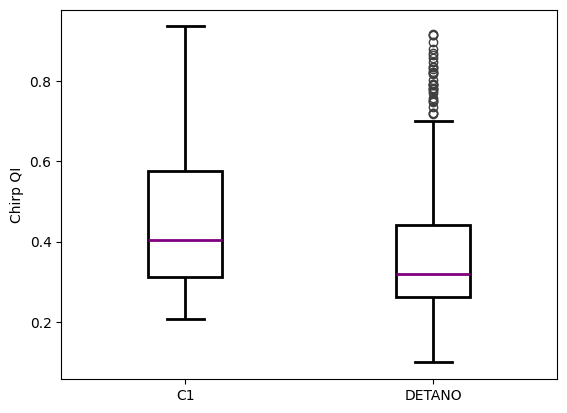

In [19]:
sns.boxplot(data=chirp_qi[(chirp_qi["date"] == datetime.date(2025, 5, 26))],
            x="cond2",
            y="qidx",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Chirp QI")

plt.savefig("plots/20250526/ChirpQI.png",
            dpi=600,
            bbox_inches="tight")

#### MB QI

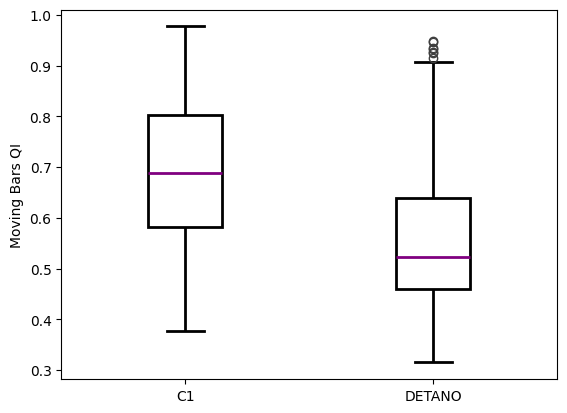

In [22]:
sns.boxplot(data=osds_indices[(osds_indices["date"] == datetime.date(2025, 5, 26))],
            x="cond2",
            y="d_qi",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Moving Bars QI")

plt.savefig("plots/20250526/MBQI.png",
            dpi=600,
            bbox_inches="tight")

### 12.06.2025, Z-offset
#### ChirpQI

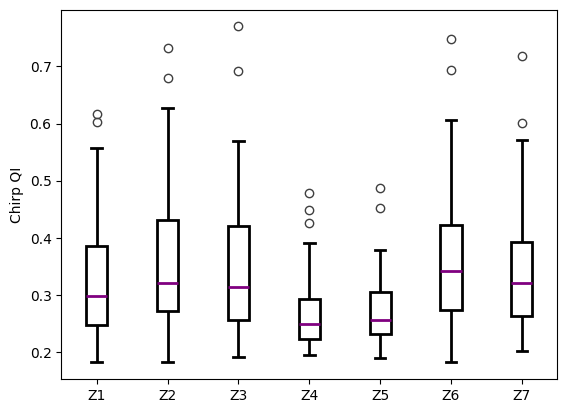

In [26]:
sns.boxplot(data=chirp_qi[(chirp_qi["date"] == datetime.date(2025, 6, 12)) & (chirp_qi["cond2"].str.startswith("Z"))],
            x="cond2",
            y="qidx",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Chirp QI")

plt.savefig("plots/20250612/ChirpQI_Z_offset.png",
            dpi=600,
            bbox_inches="tight")

#### MB QI

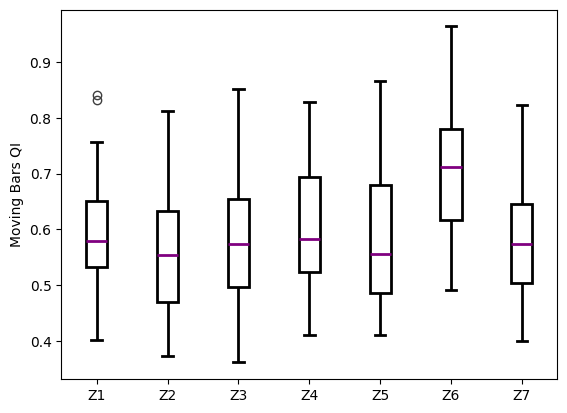

In [30]:
sns.boxplot(data=osds_indices[(osds_indices["date"] == datetime.date(2025, 6, 12)) & (osds_indices["cond2"].str.startswith("Z"))],
            x="cond2",
            y="d_qi",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Moving Bars QI")

plt.savefig("plots/20250612/MBQI_offset.png",
            dpi=600,
            bbox_inches="tight")

### 12.06.2025, C1-C4
#### ChirpQI

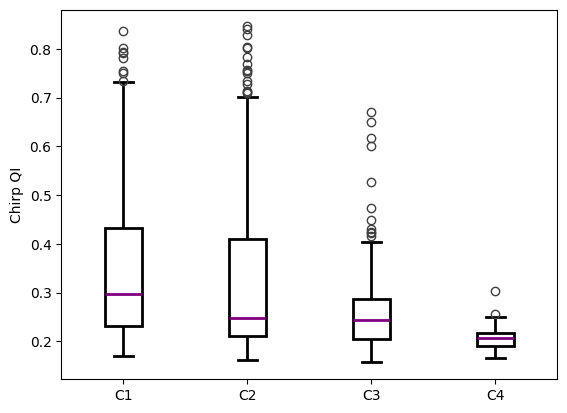

In [31]:
sns.boxplot(data=chirp_qi[(chirp_qi["date"] == datetime.date(2025, 6, 12)) & (chirp_qi["cond2"].str.startswith("C"))],
            x="cond2",
            y="qidx",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Chirp QI")

plt.savefig("plots/20250612/ChirpQI_rundown.png",
            dpi=600,
            bbox_inches="tight")

#### MB QI

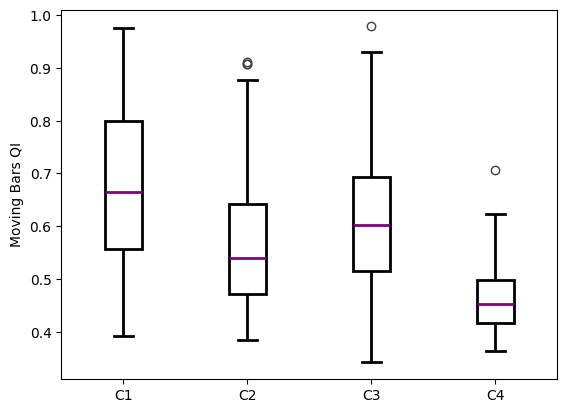

In [32]:
sns.boxplot(data=osds_indices[(osds_indices["date"] == datetime.date(2025, 6, 12)) & (osds_indices["cond2"].str.startswith("C"))],
            x="cond2",
            y="d_qi",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Moving Bars QI")

plt.savefig("plots/20250612/MBQI_rundown.png",
            dpi=600,
            bbox_inches="tight")

### 10.07.2025
#### ChirpQI

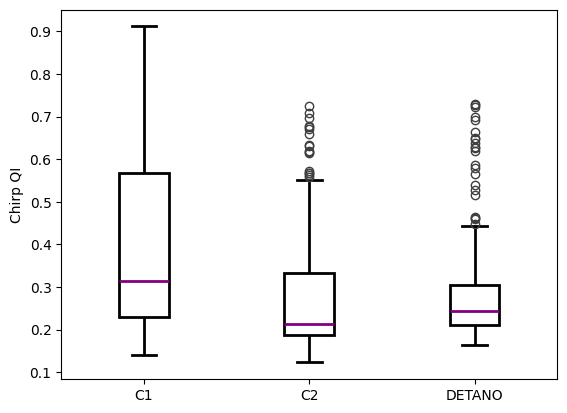

In [35]:
sns.boxplot(data=chirp_qi[(chirp_qi["date"] == datetime.date(2025, 7, 10))],
            x="cond2",
            y="qidx",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Chirp QI")

plt.savefig("plots/20250710/ChirpQI.png",
            dpi=600,
            bbox_inches="tight")

#### MB QI

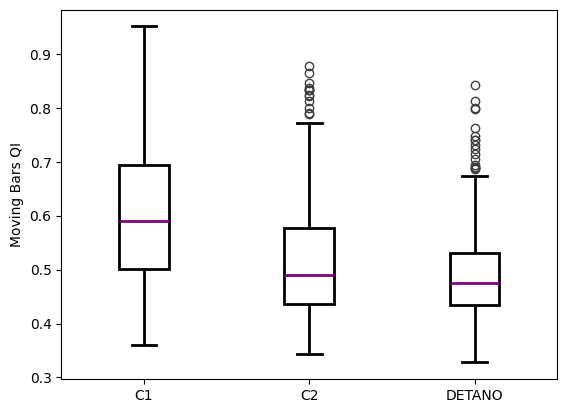

In [36]:
sns.boxplot(data=osds_indices[(osds_indices["date"] == datetime.date(2025, 7, 10))],
            x="cond2",
            y="d_qi",
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='purple', linewidth=2),
            width=0.3)

plt.xlabel(None)
plt.ylabel("Moving Bars QI")

plt.savefig("plots/20250710/MBQI.png",
            dpi=600,
            bbox_inches="tight")